# Overlap of DEGs
For both phase 1 oysters and phase 2 oysters, I ran DESeq but isolated the effects of phase 1 (and 2) temperature and DO treatments (so identified DEGs for phase 2 warm vs. ambient, ignoring the effects of phase 1 and phase 2 DO treamtents). I'm now curious if there is overlap between the DEGs I've identified in phase 1 and phase 2.

## 0. load libraries

In [2]:
library(tidyverse)
library(UpSetR)

## 1. load CSVs

#### phase 1 oysters

In [12]:
p1_DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/hypoxic_v_normoxic.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p1_DO) # 65 DEGs

[1] 65  8

In [6]:
p1_temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/warm_v_ambient.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p1_temp) # 100 DEGs

[1] 100   8

#### phase 2 oysters

In [7]:
p2_p1.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p1_DO.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p1.DO) # 55 DEGs

[1]  55 102

In [8]:
p2_p1.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p1_temp.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p1.temp) # 27 DEGs

[1]  27 102

In [9]:
p2_p2.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p2_DO.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p2.DO) # 67 DEGs

[1]  67 102

In [17]:
p2_p2.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p2_temp.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p2.temp) # 167 DEGs

[1] 167 102

## 2. UpSet Plots

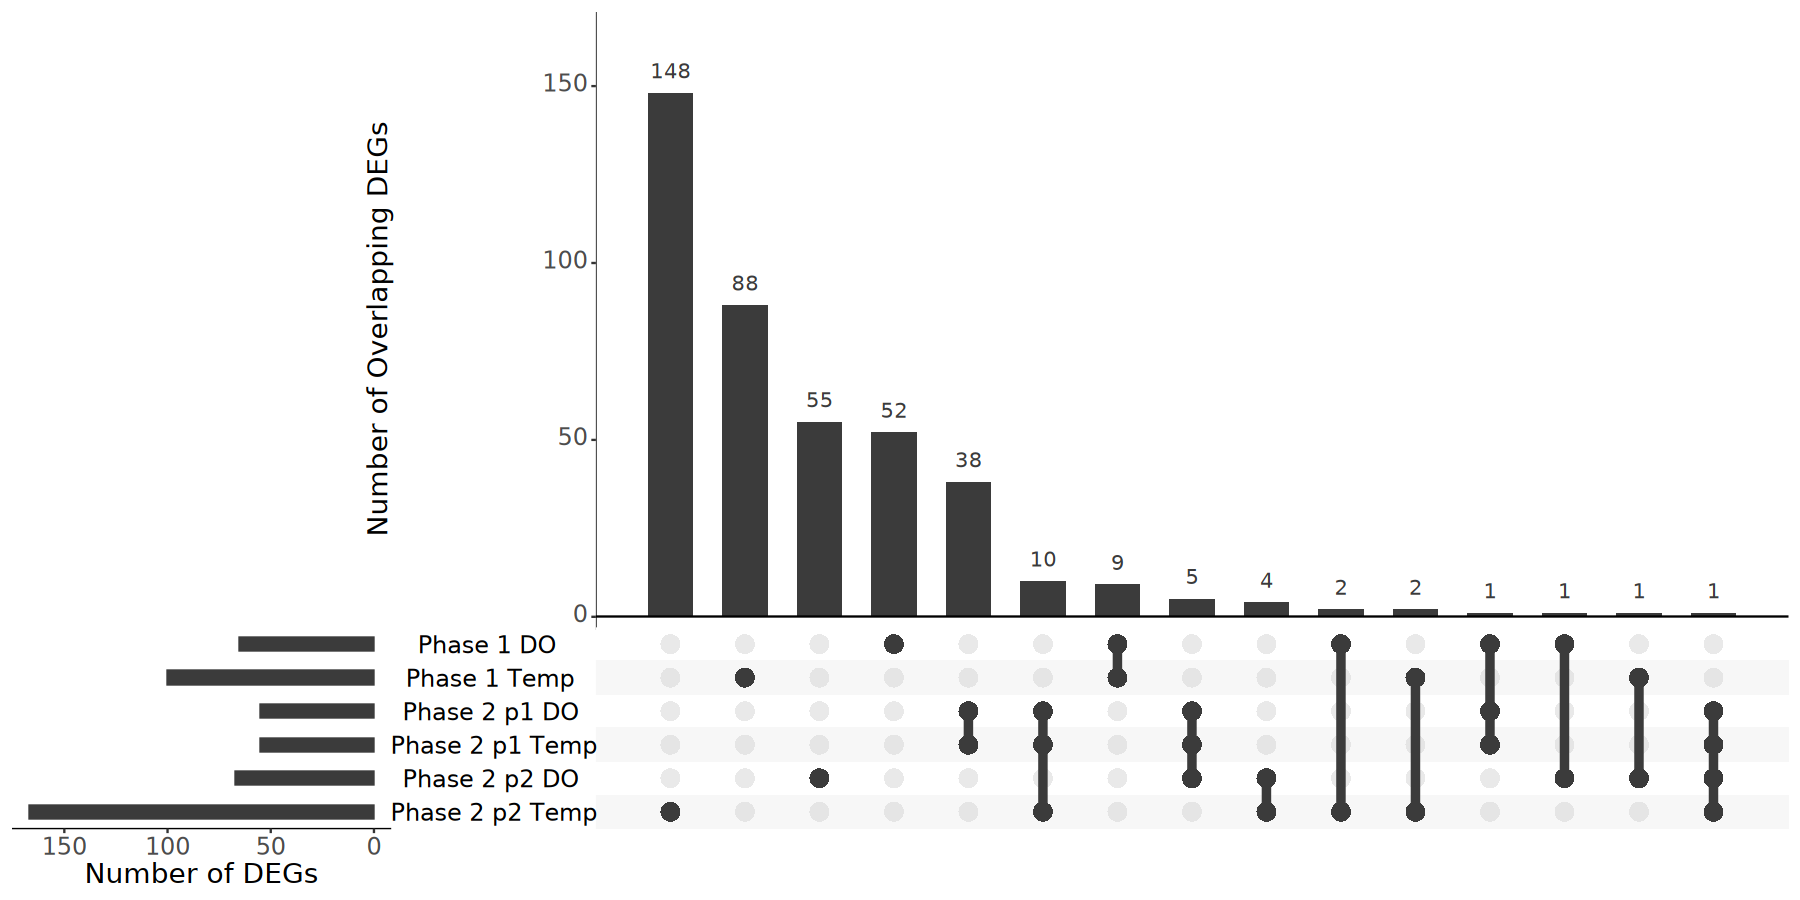

In [24]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

# make list for input into upset
DEGs = list('Phase 1 DO' = p1_DO$X,
            'Phase 1 Temp' = p1_temp$X,
            'Phase 2 p1 DO' = p2_p1.DO$Gene,
            'Phase 2 p1 Temp' = p2_p1.DO$Gene,
            'Phase 2 p2 DO' = p2_p2.DO$Gene,
            'Phase 2 p2 Temp' = p2_p2.temp$Gene)

# plot
upset(
  fromList(DEGs),
    sets = rev(names(DEGs)),   # enforce order
  keep.order = TRUE,
  order.by = "freq",
  nsets = 6,
  point.size = 5,
  line.size = 2,
  mainbar.y.label = "Number of Overlapping DEGs",
  sets.x.label = "Number of DEGs",
  text.scale = c(2, 2, 2, 2, 2, 2)
)

- 38 DEGs are shared in phase 2 oysters phase 1 treatments (so general response to early stressors? "memory" genes?)
- there are not many DEGs that are shared between phase 1 and phase 2 oysters
    - 2 shared between phase 2 p2 temp and phase 1 DO (??)
    - 2 shared between phase 2 p2 temp and phase 1 temp (interesting! maintained expr/memory of past environment? would be interesting to see if they're similarly expressed)
    - there are other DEGs that are shared between phase 1 and 2 oysters but there's only 1 for each grouping (right of the plot)
- 1 DEG that is shared in all of the Phase 2 oysters 

## 3. Shared genes
Pulling out the shared genes to investigate more